Caricamento CCLE...
CCLE bin: 2885 | gain: 217 | loss: 31

=== Full coverage (100%) ===
  gain: sens=0.871 spec=0.794
  loss: sens=0.226 spec=0.724

=== cov_67 (coverage=0.67) ===
  rep_01: OK
  rep_02: OK
  rep_03: OK
  rep_04: OK
  rep_05: OK
  rep_06: OK
  rep_07: OK
  rep_08: OK
  rep_09: OK
  rep_10: OK
  rep_11: OK
  rep_12: OK
  rep_13: OK
  rep_14: OK
  rep_15: OK
  rep_16: OK
  rep_17: OK
  rep_18: OK
  rep_19: OK
  rep_20: OK
  rep_21: OK
  rep_22: OK
  rep_23: OK
  rep_24: OK
  rep_25: OK
  rep_26: OK
  rep_27: OK
  rep_28: OK
  rep_29: OK
  rep_30: OK
  rep_31: OK
  rep_32: OK
  rep_33: OK
  rep_34: OK
  rep_35: OK
  rep_36: OK
  rep_37: OK
  rep_38: OK
  rep_39: OK
  rep_40: OK
  rep_41: OK
  rep_42: OK
  rep_43: OK
  rep_44: OK
  rep_45: OK
  rep_46: OK
  rep_47: OK
  rep_48: OK
  rep_49: OK
  rep_50: OK
  rep_51: OK
  rep_52: OK
  rep_53: OK
  rep_54: OK
  rep_55: OK
  rep_56: OK
  rep_57: OK
  rep_58: OK
  rep_59: OK
  rep_60: OK
  rep_61: OK
  rep_62: OK
  rep_63: OK
 

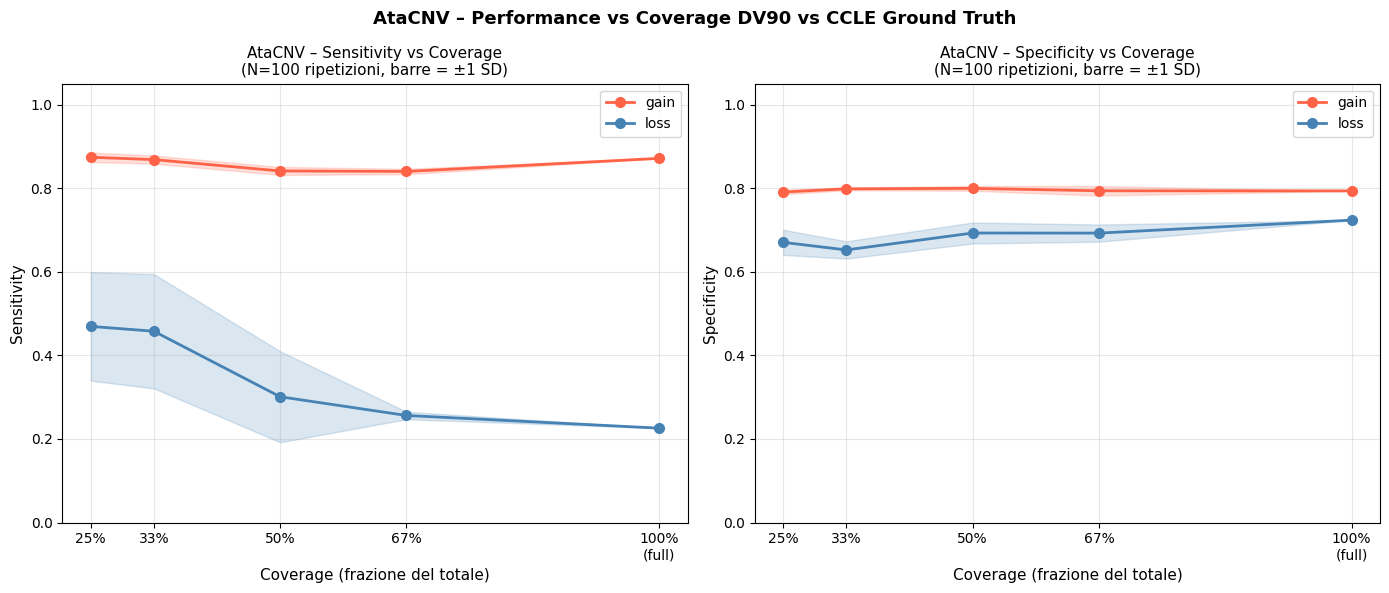

Salvato: /sharedFolder/Results/AtaCNV/coverage_analysis/coverage_performance_plot.png


In [1]:
#!/usr/bin/env python3
"""
coverage_metrics.py
Legge tutti i copy_ratio.rds salvati da coverage_analysis.R,
calcola metriche vs CCLE ground truth e genera il plot finale.
Il punto a 100% viene calcolato dal copy_ratio.csv del run completo.
Da lanciare DOPO che coverage_analysis.R ha finito.
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyreadr

# ── Percorsi ─────────────────────────────────────────────
COV_DIR      = "/sharedFolder/Results/AtaCNV/coverage_analysis"
FULL_CR_CSV  = "/sharedFolder/Results/AtaCNV/DV90/cnv/copy_ratio.csv"
CCLE_F       = "/sharedFolder/Data/DV90_CCLE_ABSOLUTE_combined_20181227.xlsx"
OUT_CSV      = os.path.join(COV_DIR, "coverage_results.csv")
OUT_PNG      = os.path.join(COV_DIR, "coverage_performance_plot.png")

COVERAGES  = {"cov_67": 2/3, "cov_50": 1/2, "cov_33": 1/3, "cov_25": 1/4}
N_REPS     = 100

# ── CCLE ground truth ─────────────────────────────────────
print("Caricamento CCLE...")
ccle_raw  = pd.read_excel(CCLE_F, sheet_name="ABSOLUTE_combined.segtab")
ccle_dv90 = ccle_raw[ccle_raw["sample"] == "DV90_LUNG"].copy()
ccle_dv90["chr"] = "chr" + ccle_dv90["Chromosome"].astype(int).astype(str)

BIN_SIZE = 1_000_000
rows = []
for _, seg in ccle_dv90.iterrows():
    for b in range(int(seg["Start"] // BIN_SIZE) * BIN_SIZE,
                   int(seg["End"]   // BIN_SIZE) * BIN_SIZE + BIN_SIZE,
                   BIN_SIZE):
        cn   = seg["Modal_Total_CN"]
        call = "gain" if cn > 2 else ("loss" if cn < 2 else "neutral")
        rows.append({"chr": seg["chr"], "start": b,
                     "ccle_cn": cn, "ccle_call": call})
ccle_bins = pd.DataFrame(rows)
print(f"CCLE bin: {len(ccle_bins)} | gain: {(ccle_bins.ccle_call=='gain').sum()} | loss: {(ccle_bins.ccle_call=='loss').sum()}")

# ── Funzione metriche ─────────────────────────────────────
def calc_metrics(cr_df, ccle_bins):
    merged = ccle_bins.merge(cr_df, on=["chr","start"], how="inner")
    if len(merged) == 0:
        return None
    out = {}
    for cna in ["gain","loss"]:
        tp = ((merged.ccle_call == cna) & (merged.call == cna)).sum()
        fn = ((merged.ccle_call == cna) & (merged.call != cna)).sum()
        fp = ((merged.ccle_call != cna) & (merged.call == cna)).sum()
        tn = ((merged.ccle_call != cna) & (merged.call != cna)).sum()
        out[cna] = {
            "sensitivity": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
            "specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
            "tp": tp, "fn": fn, "fp": fp, "tn": tn
        }
    return out

def cr_csv_to_df(cr, thresholds=(1.05, 0.95)):
    """Converte un DataFrame celle x bin in cr_df con chr, start, cr_mean, call."""
    cr_mean = cr.mean(axis=0)
    chrs    = [c.split("_")[0] for c in cr.columns]
    starts  = [int(float(c.split("_")[1])) for c in cr.columns]
    cr_df   = pd.DataFrame({"chr": chrs, "start": starts, "cr_mean": cr_mean.values})
    cr_df["call"] = cr_df["cr_mean"].apply(
        lambda x: "gain" if x > thresholds[0] else ("loss" if x < thresholds[1] else "neutral"))
    return cr_df

# ── Full coverage (100%) dal CSV reale ────────────────────
print("\n=== Full coverage (100%) ===")
cr_full    = pd.read_csv(FULL_CR_CSV, index_col=0)
cr_df_full = cr_csv_to_df(cr_full)
metrics_full = calc_metrics(cr_df_full, ccle_bins)

all_rows = []
if metrics_full:
    for cna, m in metrics_full.items():
        all_rows.append({
            "coverage": 1.0, "cov_label": "cov_100", "rep": 1,
            "cna_type": cna,
            "sensitivity": m["sensitivity"], "specificity": m["specificity"],
            "tp": m["tp"], "fn": m["fn"], "fp": m["fp"], "tn": m["tn"]
        })
    print(f"  gain: sens={metrics_full['gain']['sensitivity']:.3f} spec={metrics_full['gain']['specificity']:.3f}")
    print(f"  loss: sens={metrics_full['loss']['sensitivity']:.3f} spec={metrics_full['loss']['specificity']:.3f}")

# ── Loop su tutti i coverage subsamplings ────────────────
for cov_label, cov_frac in COVERAGES.items():
    print(f"\n=== {cov_label} (coverage={cov_frac:.2f}) ===")
    for rep in range(1, N_REPS + 1):
        cr_file = os.path.join(COV_DIR, cov_label, f"rep_{rep:02d}", "copy_ratio.rds")
        if not os.path.exists(cr_file):
            print(f"  rep_{rep:02d}: FILE NON TROVATO - skip")
            continue

        try:
            cr_dict = pyreadr.read_r(cr_file)
            cr      = list(cr_dict.values())[0]
        except Exception as e:
            print(f"  rep_{rep:02d}: ERRORE lettura - {e}")
            continue

        cr_df   = cr_csv_to_df(cr)
        metrics = calc_metrics(cr_df, ccle_bins)
        if metrics is None:
            print(f"  rep_{rep:02d}: merge vuoto - skip")
            continue

        for cna, m in metrics.items():
            all_rows.append({
                "coverage":    cov_frac,
                "cov_label":   cov_label,
                "rep":         rep,
                "cna_type":    cna,
                "sensitivity": m["sensitivity"],
                "specificity": m["specificity"],
                "tp": m["tp"], "fn": m["fn"],
                "fp": m["fp"], "tn": m["tn"]
            })
        print(f"  rep_{rep:02d}: OK")

# ── Salva risultati ───────────────────────────────────────
results_df = pd.DataFrame(all_rows)
results_df.to_csv(OUT_CSV, index=False)
print(f"\nSalvato: {OUT_CSV} ({len(results_df)} righe)")

# ── Summary ───────────────────────────────────────────────
summary = results_df.groupby(["coverage","cna_type"]).agg(
    sens_mean = ("sensitivity","mean"),
    sens_sd   = ("sensitivity","std"),
    spec_mean = ("specificity","mean"),
    spec_sd   = ("specificity","std"),
    n_reps    = ("rep","count")
).reset_index().sort_values(["cna_type","coverage"])

print("\n=== Summary ===")
print(summary.to_string(index=False))

# ── Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_map = {"gain": "tomato", "loss": "steelblue"}
cov_order  = [0.25, 1/3, 0.5, 2/3, 1.0]
cov_xlabels = ["25%", "33%", "50%", "67%", "100%\n(full)"]

for ax, metric, sd_col, ylabel in zip(
    axes,
    ["sens_mean", "spec_mean"],
    ["sens_sd",   "spec_sd"],
    ["Sensitivity", "Specificity"]
):
    for cna in ["gain", "loss"]:
        sub = summary[summary["cna_type"] == cna].sort_values("coverage")
        x   = sub["coverage"].values
        y   = sub[metric].values
        sd  = sub[sd_col].fillna(0).values

        ax.plot(x, y, marker="o", color=colors_map[cna],
                linewidth=2, markersize=7, label=cna)
        ax.fill_between(x, y - sd, y + sd, alpha=0.2, color=colors_map[cna])

    ax.set_xlabel("Coverage (frazione del totale)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f"AtaCNV – {ylabel} vs Coverage\n(N=100 ripetizioni, barre = ±1 SD)",
                 fontsize=11)
    ax.set_xticks(cov_order)
    ax.set_xticklabels(cov_xlabels)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle("AtaCNV – Performance vs Coverage DV90 vs CCLE Ground Truth",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvato: {OUT_PNG}")

In [2]:
import pyreadr
import pandas as pd

cr = pyreadr.read_r("/sharedFolder/Results/AtaCNV/DV90/count.rds")
count = list(cr.values())[0]

frags = count.sum(axis=1)
print(f"Totale frammenti unici: {frags.sum():,.0f}")
print(f"Media per cella:        {frags.mean():,.0f}")
print(f"Mediana per cella:      {frags.median():,.0f}")
print(f"Min per cella:          {frags.min():,.0f}")
print(f"Max per cella:          {frags.max():,.0f}")

Totale frammenti unici: 183,873,732
Media per cella:        52,959
Mediana per cella:      35,947
Min per cella:          185
Max per cella:          1,030,838
